# Camera example
A simple example showing off some of the functionality of visgeom.

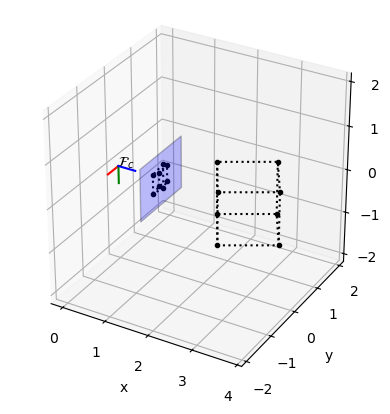

In [1]:
#%matplotlib notebook

import matplotlib.pyplot as plt
import visgeom as vg
import numpy as np
from scipy.spatial.transform import Rotation

# Create axis.
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

# Camera intrinsics and pose.
K = np.array([[50, 0, 40],
              [0, 50, 30],
              [0, 0, 1]])
R_w_c = np.array([[0, 0, 1],
                  [-1, 0, 0],
                  [0, -1, 0]])
t_w_c = np.zeros((3, 1))

# Plot camera.
vg.plot_pose(ax, (R_w_c, t_w_c), scale=0.4, text='$\\mathcal{F}_c$')
vg.plot_camera_image_plane(ax, K, (R_w_c, t_w_c), scale=1)

# Plot a box in 3D.
R_w_b = Rotation.from_rotvec([0, 0, np.pi / 6]).as_matrix()
t_w_b = np.array([[3, 0, 0]]).T
points_w = vg.utils.generate_box(pose=(R_w_b, t_w_b), scale=0.6)
vg.utils.plot_as_box(ax, points_w)

# Project the box onto the image plane.
points_c = R_w_c.T @ points_w + (R_w_c.T @ t_w_c)
xn = points_c / points_c[2, :]
xn_w = R_w_c @ xn - t_w_c
vg.utils.plot_as_box(ax, xn_w)

# Show figure.
vg.plot.axis_equal(ax)
plt.show()